In [2]:
!pip install -qq gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 48.0 MB/s eta 0:00:00


Vocabulary: ['juice', 'healthy', 'milk', 'are', 'apple', 'and', 'food', 'is', 'daily', 'eggs', 'orange', 'i', 'likes', 'sweet', 'drinks', 'he', 'she', 'drink', 'items', 'fruits', 'eat', 'a', 'eats', 'like']

Nearest neighbours:

orange -> [('a', 0.9600497484207153), ('milk', 0.9405094385147095), ('juice', 0.926250696182251), ('are', 0.9063442945480347), ('and', 0.8914839625358582)]
apple -> [('food', 0.9384748339653015), ('eats', 0.9002224802970886), ('and', 0.8883225917816162), ('eat', 0.8803808093070984), ('she', 0.8558645248413086)]
juice -> [('healthy', 0.9518908858299255), ('a', 0.9292293190956116), ('milk', 0.9277775287628174), ('orange', 0.9262505769729614), ('daily', 0.9205979108810425)]
milk -> [('orange', 0.940509557723999), ('a', 0.9383086562156677), ('healthy', 0.9382230639457703), ('juice', 0.9277777075767517), ('food', 0.9230586886405945)]
eggs -> [('likes', 0.9179641604423523), ('eat', 0.9160587191581726), ('and', 0.9101837277412415), ('milk', 0.877871572971344), ('food'

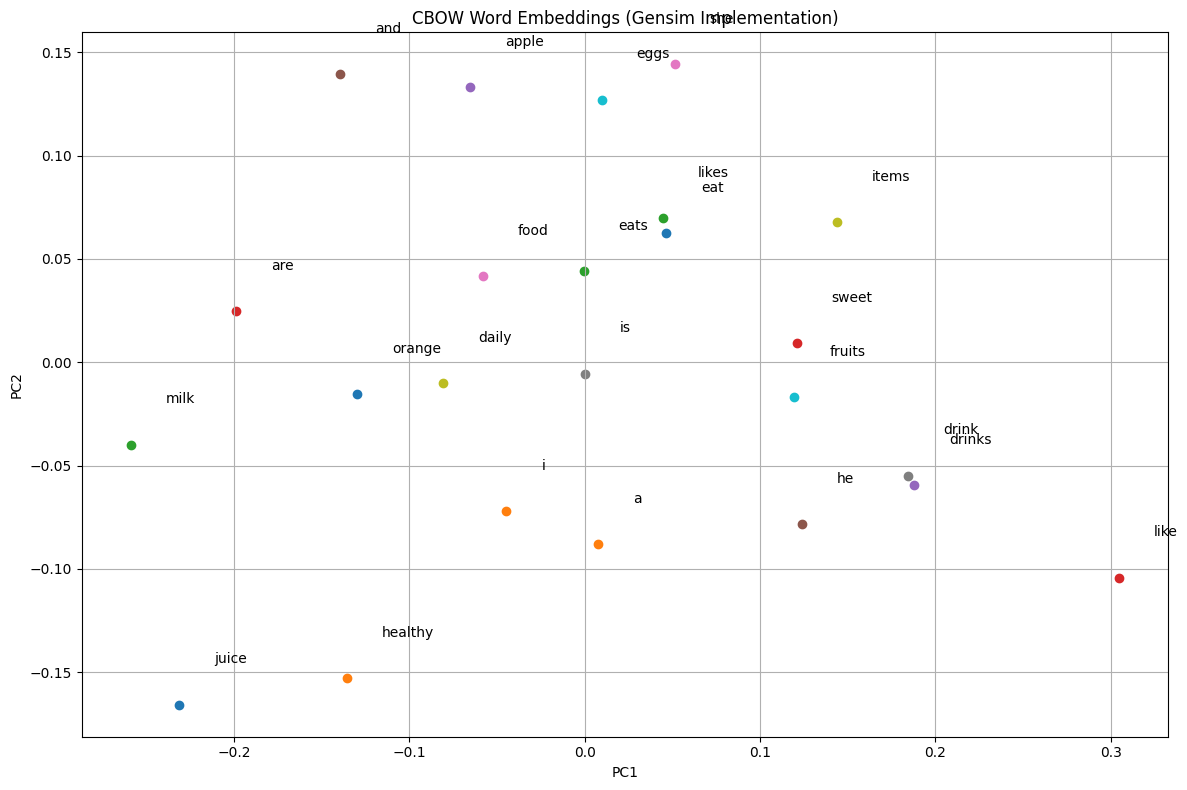

In [3]:
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# ------------------------------------------------------------
# 1. Curated Micro-Corpus (same as before)
# ------------------------------------------------------------
corpus = [
    "I like orange juice",
    "I drink apple juice",
    "She eats eggs daily",
    "He drinks milk daily",
    "Orange juice is healthy",
    "Apple juice is sweet",
    "Eggs are healthy food",
    "Milk is a healthy drink",
    "I eat healthy food daily",
    "She likes sweet apple juice",
    "He likes healthy milk",
    "Orange and apple are fruits",
    "Milk and juice are drinks",
    "Eggs and milk are food items"
]

# Tokenize
tokenized_corpus = [sentence.lower().split() for sentence in corpus]

# ------------------------------------------------------------
# 2. Train CBOW using Gensim
# ------------------------------------------------------------
model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=10,   # embedding dimension
    window=2,         # context window
    min_count=1,      # include all words
    sg=0,             # 0 = CBOW, 1 = Skip-Gram
    epochs=500
)

print("Vocabulary:", list(model.wv.index_to_key))

# ------------------------------------------------------------
# 3. Extract embeddings
# ------------------------------------------------------------
words = model.wv.index_to_key
embeddings = np.array([model.wv[word] for word in words])

# ------------------------------------------------------------
# 4. Show similarity examples
# ------------------------------------------------------------
print("\nNearest neighbours:\n")

for word in ["orange", "apple", "juice", "milk", "eggs"]:
    print(f"{word} -> {model.wv.most_similar(word, topn=5)}")

# ------------------------------------------------------------
# 5. Reduce to 2D using PCA
# ------------------------------------------------------------
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# ------------------------------------------------------------
# 6. Plot embeddings
# ------------------------------------------------------------
plt.figure(figsize=(12, 8))

for i, word in enumerate(words):
    x, y = embeddings_2d[i]
    plt.scatter(x, y)
    plt.text(x + 0.02, y + 0.02, word, fontsize=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("CBOW Word Embeddings (Gensim Implementation)")
plt.grid(True)
plt.tight_layout()
plt.show()